# **Preprocessing & Feature Engineering**

## Introduction

Objective of this notebook:

- Load cleaned dataset

- Create multiclass target

- Engineer new features

- Build binary and multiclass datasets

- Split data

- Apply preprocessing pipeline

- Validate no leakage

- Save final artifacts


This notebook produces:

```text
data/processed/
│
├── binary_full_dataset.csv
├── multiclass_full_dataset.csv
├── binary_dataset.pkl
├── multiclass_dataset.pkl

artifacts/
|
├── preprocessor.pkl

```

## Imports

In [56]:
import pandas as pd
import numpy as np
import joblib
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")

from preprocessing import (
    create_multiclass_target,
    drop_failure_columns,
    build_binary_dataset,
    build_multiclass_dataset,
    split_data,
    build_full_preprocessing_pipeline
)

## Load Cleaned Dataset

In [57]:
df = pd.read_csv("../data/interim/cleaned_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 12)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


At this stage:

- ID & UDI removed

- Raw failure columns still exist

- No engineered features yet

## Create Multiclass Target

In [58]:
df = create_multiclass_target(df)

df["Failure Type"].value_counts()

Failure Type
No Failure          9652
HDF                  106
PWF                   80
OSF                   78
TWF                   42
Multiple Failure      24
RNF                   18
Name: count, dtype: int64

### Visualize Class Distribution

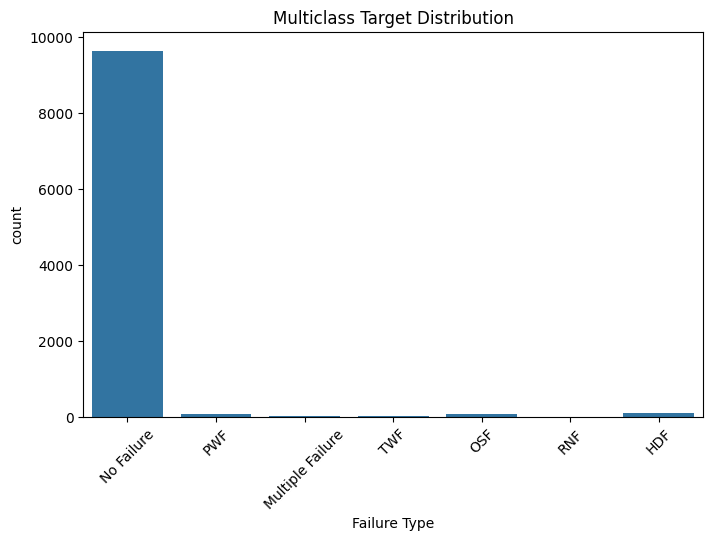

In [59]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Failure Type")
plt.xticks(rotation=45)
plt.title("Multiclass Target Distribution")
plt.show()

- Observe strong class imbalance

- Majority class likely “No Failure”

- Important for later model handling

## Drop Individual Failure Columns (Leakage Prevention)

In [60]:
df = drop_failure_columns(df)

print("Remaining columns:")
print(df.columns)

Remaining columns:
Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'Failure Type'],
      dtype='str')


If we leave:

PWF, OSF, TWF, HDF, RNF

The model would directly see failure indicators.

That would be data leakage.

Engineered Features Typically Include:

- Temperature difference

- Power (Torque × Rotational speed)


Engineered features help the model learn:

- Mechanical stress

- Thermal instability

- Energy load

## Save Full Ready Datasets (No Split)

These are reusable research datasets.

In [61]:
df_full = df.copy()

binary_full = df_full.drop(columns=["Failure Type"])
multiclass_full = df_full.drop(columns=["Machine failure"])

os.makedirs("../data/processed", exist_ok=True)

binary_full.to_csv("../data/processed/binary_full_dataset.csv", index=False)
multiclass_full.to_csv("../data/processed/multiclass_full_dataset.csv", index=False)

print("Full datasets saved.")

Full datasets saved.


In [62]:
binary_full.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [63]:
multiclass_full.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Type
0,M,298.1,308.6,1551,42.8,0,No Failure
1,L,298.2,308.7,1408,46.3,3,No Failure
2,L,298.1,308.5,1498,49.4,5,No Failure
3,L,298.2,308.6,1433,39.5,7,No Failure
4,L,298.2,308.7,1408,40.0,9,No Failure


## Build Modeling Datasets

In [64]:
X_binary, y_binary = build_binary_dataset(df)
X_multi, y_multi = build_multiclass_dataset(df)

print("Binary shape:", X_binary.shape)
print("Multiclass shape:", X_multi.shape)

Binary shape: (10000, 6)
Multiclass shape: (10000, 6)


## Train/Test Split

In [65]:
Xb_train, Xb_test, yb_train, yb_test = split_data(X_binary, y_binary)
Xm_train, Xm_test, ym_train, ym_test = split_data(X_multi, y_multi)

print("Binary Train:", Xb_train.shape)
print("Binary Test:", Xb_test.shape)

Binary Train: (7000, 6)
Binary Test: (3000, 6)


## Validate Split Ratio

In [66]:
print("Train ratio:", len(yb_train)/len(y_binary))
print("Test ratio:", len(yb_test)/len(y_binary))

Train ratio: 0.7
Test ratio: 0.3


## Check Target Balance After Split

In [67]:
print("Binary Train Distribution:")
print(yb_train.value_counts(normalize=True))

print("\nBinary Test Distribution:")
print(yb_test.value_counts(normalize=True))

Binary Train Distribution:
Machine failure
0    0.966143
1    0.033857
Name: proportion, dtype: float64

Binary Test Distribution:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


In [68]:
print("Multi Train Distribution:")
print(ym_train.value_counts(normalize=True))

print("\nMulti Test Distribution:")
print(ym_test.value_counts(normalize=True))

Multi Train Distribution:
Failure Type
No Failure          0.965143
HDF                 0.010571
PWF                 0.008000
OSF                 0.007857
TWF                 0.004143
Multiple Failure    0.002429
RNF                 0.001857
Name: proportion, dtype: float64

Multi Test Distribution:
Failure Type
No Failure          0.965333
HDF                 0.010667
PWF                 0.008000
OSF                 0.007667
TWF                 0.004333
Multiple Failure    0.002333
RNF                 0.001667
Name: proportion, dtype: float64


**This confirms stratification worked.**

## Build Preprocessing Pipeline

In [69]:
preprocessor = build_full_preprocessing_pipeline(Xb_train)

## Apply Transformations

In [70]:
Xb_train_p = preprocessor.fit_transform(Xb_train)
Xb_test_p = preprocessor.transform(Xb_test)

Xm_train_p = preprocessor.transform(Xm_train)
Xm_test_p = preprocessor.transform(Xm_test)

## Feature Count After Encoding

In [71]:
feature_names = preprocessor.named_steps["preprocessing"].get_feature_names_out()

print("Total encoded features:", len(feature_names))

Total encoded features: 10


## Input features after preprocess and feature engineering

In [72]:
# Convert processed arrays to DataFrames
Xb_train_df = pd.DataFrame(Xb_train_p, columns=feature_names)
Xb_test_df = pd.DataFrame(Xb_test_p, columns=feature_names)

Xm_train_df = pd.DataFrame(Xm_train_p, columns=feature_names)
Xm_test_df = pd.DataFrame(Xm_test_p, columns=feature_names)

In [73]:
Xb_train_df.head(10)

,cat__Type_H,cat__Type_L,cat__Type_M,num__Air temperature [K],num__Process temperature [K],num__Rotational speed [rpm],num__Torque [Nm],num__Tool wear [min],num__Temp_diff,num__Power
0,0.0,0.0,1.0,297.8,307.4,1902.0,24.3,129.0,9.6,46218.6
1,0.0,1.0,0.0,303.7,312.3,1349.0,51.0,105.0,8.6,68799.0
2,0.0,1.0,0.0,297.2,307.9,1493.0,38.4,146.0,10.7,57331.2
3,0.0,0.0,1.0,303.6,312.3,1630.0,32.4,223.0,8.7,52812.0
4,1.0,0.0,0.0,300.9,311.9,2140.0,16.5,43.0,11.0,35310.0
5,0.0,1.0,0.0,300.4,311.8,1433.0,42.2,14.0,11.4,60472.6
6,0.0,0.0,1.0,296.0,306.7,2044.0,22.3,48.0,10.7,45581.2
7,1.0,0.0,0.0,302.1,311.6,1701.0,26.2,46.0,9.5,44566.2
8,0.0,0.0,1.0,301.0,310.9,1765.0,24.2,179.0,9.9,42713.0
9,0.0,1.0,0.0,304.0,312.8,1542.0,42.7,198.0,8.8,65843.4


In [74]:
Xm_train_df.head(10)

,cat__Type_H,cat__Type_L,cat__Type_M,num__Air temperature [K],num__Process temperature [K],num__Rotational speed [rpm],num__Torque [Nm],num__Tool wear [min],num__Temp_diff,num__Power
0,0.0,1.0,0.0,301.3,310.6,1436.0,44.2,76.0,9.3,63471.2
1,0.0,1.0,0.0,299.1,308.7,1498.0,38.9,181.0,9.6,58272.2
2,0.0,1.0,0.0,300.3,311.9,1609.0,34.0,177.0,11.6,54706.0
3,0.0,1.0,0.0,298.0,308.9,1500.0,36.7,104.0,10.9,55050.0
4,1.0,0.0,0.0,303.7,312.8,1488.0,42.8,54.0,9.1,63686.4
5,0.0,1.0,0.0,298.8,309.8,1509.0,36.2,57.0,11.0,54625.8
6,0.0,1.0,0.0,299.3,310.4,1725.0,26.8,167.0,11.1,46230.0
7,0.0,0.0,1.0,300.1,309.2,1454.0,44.4,19.0,9.1,64557.6
8,0.0,1.0,0.0,297.3,308.5,1528.0,44.5,140.0,11.2,67996.0
9,0.0,1.0,0.0,299.0,310.4,1504.0,34.3,48.0,11.4,51587.2


## Leakage Check

In [75]:
for col in feature_names:
    if any(failure in col for failure in ["TWF", "HDF", "PWF", "OSF", "RNF"]):
        print("Leakage detected:", col)

## Visualize Feature Space Size

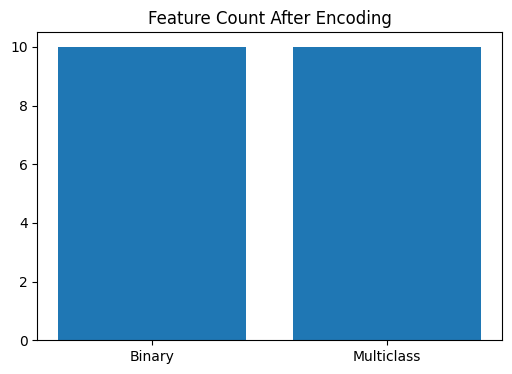

In [76]:
plt.figure(figsize=(6,4))
plt.bar(["Binary","Multiclass"],
        [Xb_train_p.shape[1], Xm_train_p.shape[1]])
plt.title("Feature Count After Encoding")
plt.show()

# **Imbalance Handling**

In [77]:
from imblearn.combine import SMOTEENN

## Apply SMOTEENN to Binary Training Set

In [78]:
# Apply SMOTEENN to Binary Training Data
smote_enn_binary = SMOTEENN(random_state=42)

Xb_train_bal, yb_train_bal = smote_enn_binary.fit_resample(
    Xb_train_p,
    yb_train
)

print("Before SMOTEENN (Binary):")
print(yb_train.value_counts())

print("\nAfter SMOTEENN (Binary):")
print(pd.Series(yb_train_bal).value_counts())

Before SMOTEENN (Binary):
Machine failure
0    6763
1     237
Name: count, dtype: int64

After SMOTEENN (Binary):
Machine failure
1    5727
0    5225
Name: count, dtype: int64


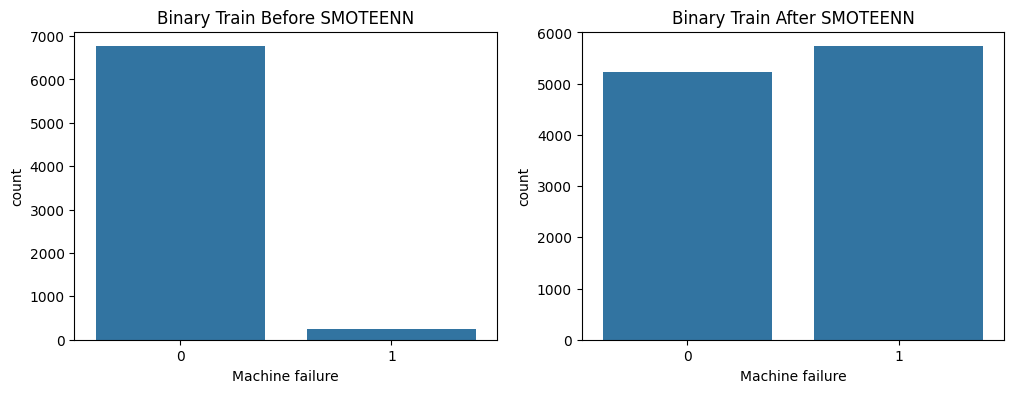

In [79]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.countplot(x=yb_train, ax=axes[0])
axes[0].set_title("Binary Train Before SMOTEENN")

sns.countplot(x=yb_train_bal, ax=axes[1])
axes[1].set_title("Binary Train After SMOTEENN")

plt.show()

## Apply SMOTEENN to Multiclass Training Set

In [80]:
# Apply SMOTEENN to Multiclass Training Data
smote_enn_multi = SMOTEENN(random_state=42)

Xm_train_bal, ym_train_bal = smote_enn_multi.fit_resample(
    Xm_train_p,
    ym_train
)

print("Before SMOTEENN (Multiclass):")
print(ym_train.value_counts())

print("\nAfter SMOTEENN (Multiclass):")
print(pd.Series(ym_train_bal).value_counts())

Before SMOTEENN (Multiclass):
Failure Type
No Failure          6756
HDF                   74
PWF                   56
OSF                   55
TWF                   29
Multiple Failure      17
RNF                   13
Name: count, dtype: int64

After SMOTEENN (Multiclass):
Failure Type
PWF                 6611
HDF                 6203
OSF                 6175
TWF                 5982
Multiple Failure    5619
RNF                 4991
No Failure          3285
Name: count, dtype: int64


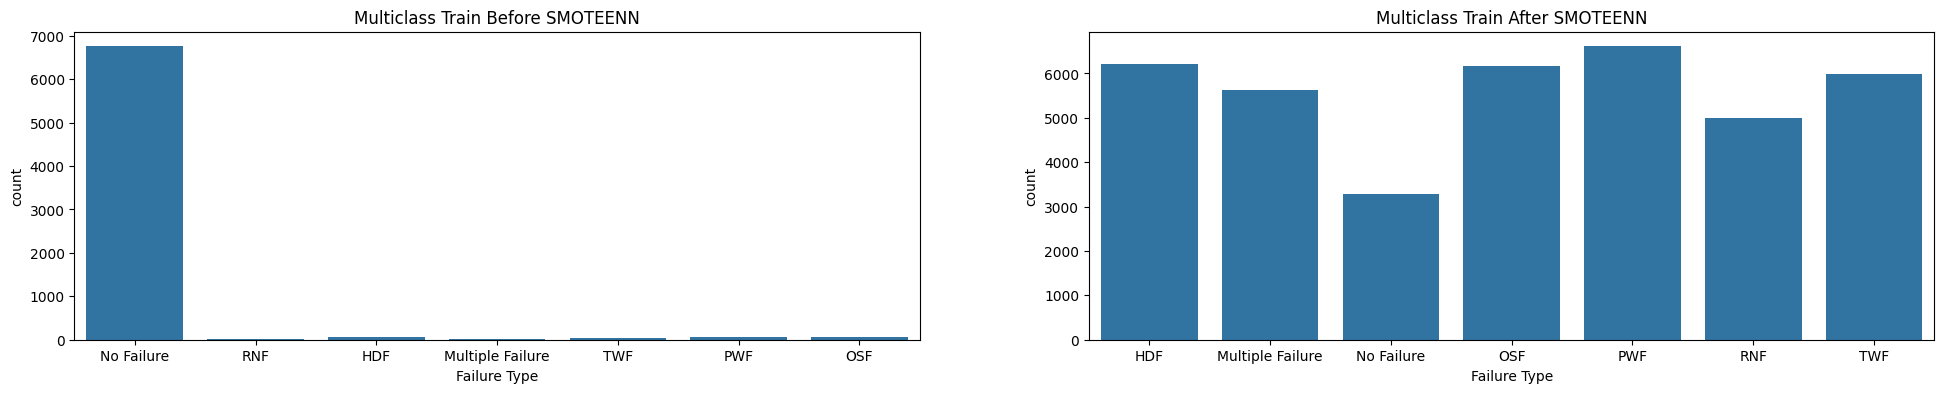

In [23]:
fig, axes = plt.subplots(1,2, figsize=(24,4))

sns.countplot(x=ym_train, ax=axes[0])
axes[0].set_title("Multiclass Train Before SMOTEENN")

sns.countplot(x=ym_train_bal, ax=axes[1])
axes[1].set_title("Multiclass Train After SMOTEENN")

plt.show()

## Visualization for original dataset

In [87]:
print("Dataset Shape:", df.shape)

display(df.head(10))

Dataset Shape: (10000, 8)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Failure Type
0,M,298.1,308.6,1551,42.8,0,0,No Failure
1,L,298.2,308.7,1408,46.3,3,0,No Failure
2,L,298.1,308.5,1498,49.4,5,0,No Failure
3,L,298.2,308.6,1433,39.5,7,0,No Failure
4,L,298.2,308.7,1408,40.0,9,0,No Failure
5,M,298.1,308.6,1425,41.9,11,0,No Failure
6,L,298.1,308.6,1558,42.4,14,0,No Failure
7,L,298.1,308.6,1527,40.2,16,0,No Failure
8,M,298.3,308.7,1667,28.6,18,0,No Failure
9,M,298.5,309.0,1741,28.0,21,0,No Failure


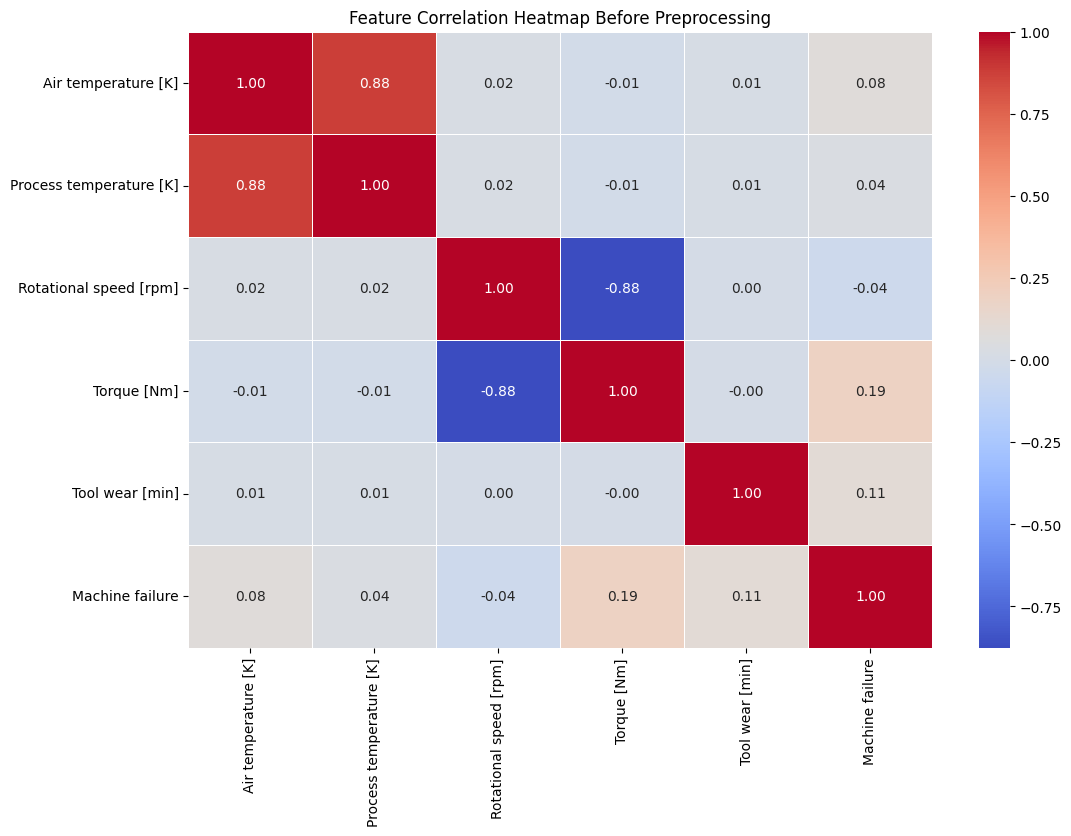

In [88]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap Before Preprocessing")
plt.show()

## Visualization for Preprocess dataset

In [89]:
# Balanced datasets
Xb_train_bal_df = pd.DataFrame(Xb_train_bal, columns=feature_names)

In [90]:
# Add target to dataframe
binary_analysis_df = Xb_train_bal_df.copy()
binary_analysis_df["Machine failure"] = yb_train_bal.values

In [93]:
binary_analysis_df.head(10)

,cat__Type_H,cat__Type_L,cat__Type_M,num__Air temperature [K],num__Process temperature [K],num__Rotational speed [rpm],num__Torque [Nm],num__Tool wear [min],num__Temp_diff,num__Power,Machine failure
0,0.0,0.0,1.0,297.8,307.4,1902.0,24.3,129.0,9.6,46218.6,0
1,0.0,1.0,0.0,303.7,312.3,1349.0,51.0,105.0,8.6,68799.0,0
2,0.0,1.0,0.0,297.2,307.9,1493.0,38.4,146.0,10.7,57331.2,0
3,1.0,0.0,0.0,300.9,311.9,2140.0,16.5,43.0,11.0,35310.0,0
4,0.0,1.0,0.0,300.4,311.8,1433.0,42.2,14.0,11.4,60472.6,0
5,0.0,0.0,1.0,296.0,306.7,2044.0,22.3,48.0,10.7,45581.2,0
6,1.0,0.0,0.0,302.1,311.6,1701.0,26.2,46.0,9.5,44566.2,0
7,0.0,0.0,1.0,301.0,310.9,1765.0,24.2,179.0,9.9,42713.0,0
8,0.0,1.0,0.0,304.0,312.8,1542.0,42.7,198.0,8.8,65843.4,0
9,0.0,1.0,0.0,299.1,310.4,1519.0,45.3,92.0,11.3,68810.7,0


In [103]:
# Convert balanced features to dataframe
Xb_train_bal_df = pd.DataFrame(Xb_train_bal, columns=feature_names)

# Convert target to pandas Series
yb_train_bal_series = pd.Series(yb_train_bal, name="Machine failure")

# Combine features and target
binary_analysis_df = pd.concat([Xb_train_bal_df, yb_train_bal_series], axis=1)

binary_analysis_df = binary_analysis_df.sample(frac=1, random_state=42).reset_index(drop=True)
binary_analysis_df.head(10)

,cat__Type_H,cat__Type_L,cat__Type_M,num__Air temperature [K],num__Process temperature [K],num__Rotational speed [rpm],num__Torque [Nm],num__Tool wear [min],num__Temp_diff,num__Power,Machine failure
0,0.0,1.000000,0.000000,299.200000,308.500000,1378.000000,50.400000,220.000000,9.300000,69451.200000,1
1,0.0,0.000000,1.000000,295.500000,306.100000,1822.000000,24.300000,164.000000,10.600000,44274.600000,0
2,0.0,0.147763,0.852237,299.094488,309.246725,1418.488021,60.818211,120.182108,10.152237,86268.190805,1
3,0.0,0.000000,1.000000,301.200000,310.100000,1666.000000,34.900000,37.000000,8.900000,58143.400000,0
4,0.0,1.000000,0.000000,297.400000,308.400000,1434.000000,39.900000,2.000000,11.000000,57216.600000,0
5,0.0,0.000000,1.000000,300.500000,311.500000,1378.000000,48.200000,82.000000,11.000000,66419.600000,0
6,0.0,1.000000,0.000000,298.000000,308.300000,1473.000000,42.600000,107.000000,10.300000,62749.800000,0
7,0.0,1.000000,0.000000,299.000000,309.400000,1419.000000,48.300000,91.000000,10.400000,68537.700000,0
8,0.0,1.000000,0.000000,298.920627,308.723126,1317.950026,67.636665,31.360270,9.802499,89138.744500,1
9,0.0,1.000000,0.000000,300.200000,311.600000,1827.000000,27.000000,22.000000,11.400000,49329.000000,0


In [104]:
binary_analysis_df["Machine failure"].value_counts()

Machine failure
1    5727
0    5225
Name: count, dtype: int64

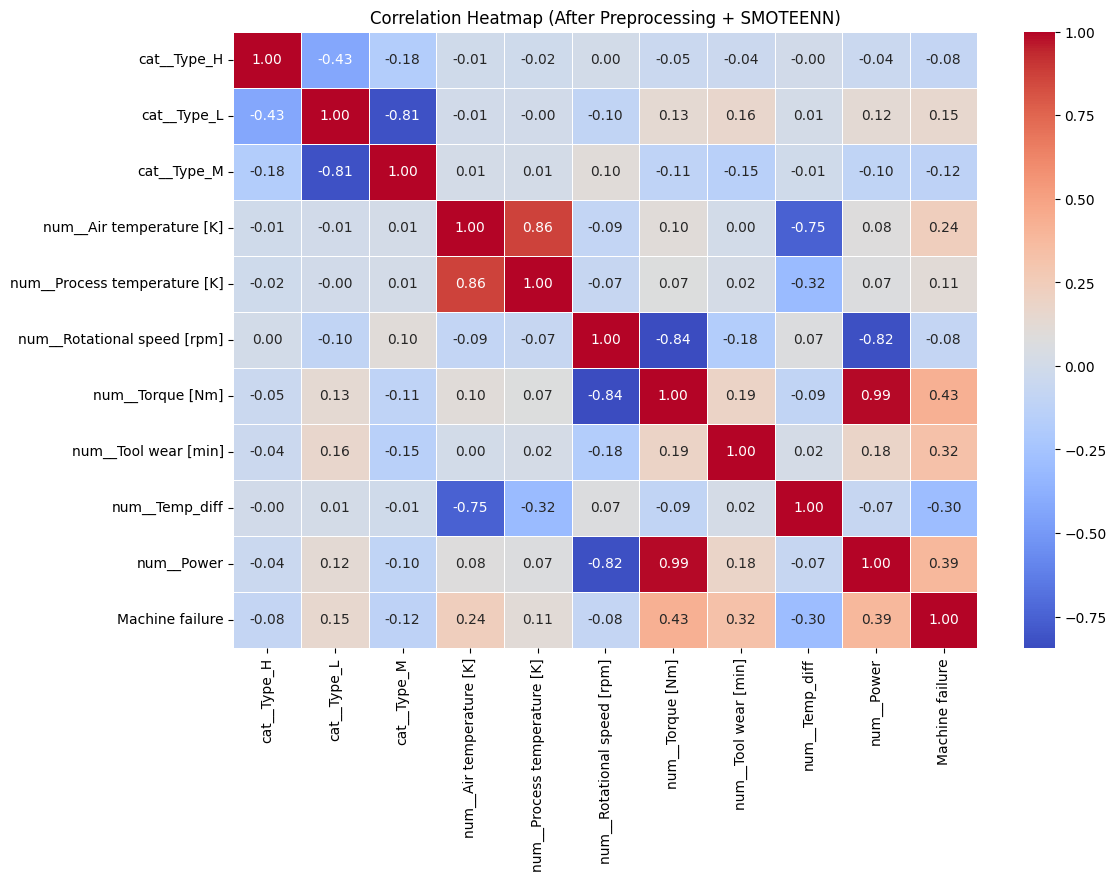

In [105]:
plt.figure(figsize=(12,8))

corr = binary_analysis_df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap (After Preprocessing + SMOTEENN)")
plt.show()

After applying preprocessing, feature engineering, and SMOTEENN balancing, the correlation between features(etc.num_torque) and the binary target Machine failure increased (from 0.19 (original dataset) to 0.43 (balanced training dataset)).

This change is expected because class imbalance in the original dataset suppressed the relationship between features and the failure class. After balancing the dataset, the model can better capture the relationship between torque-related features and machine failures.

## Final Clean Saving Artifacts

In [24]:
# Save Preprocessor
os.makedirs("../artifacts", exist_ok=True)

joblib.dump(preprocessor, "../artifacts/preprocessing_pipeline.pkl")
print("Deployment-ready preprocessing pipeline saved successfully.")
# joblib.dump(preprocessor, "../data/processed/preprocessor.pkl")

# Save Binary Dataset (Balanced Train + Original Test)
pd.to_pickle(
    (Xb_train_bal, Xb_test_p, yb_train_bal, yb_test),
    "../data/processed/binary_dataset.pkl"
)

# Save Multiclass Dataset (Balanced Train + Original Test)
pd.to_pickle(
    (Xm_train_bal, Xm_test_p, ym_train_bal, ym_test),
    "../data/processed/multiclass_dataset.pkl"
)

print("Processed datasets with SMOTEENN saved successfully.")

Deployment-ready preprocessing pipeline saved successfully.
Processed datasets with SMOTEENN saved successfully.


# Final Dataset Summary

| Dataset                       | Purpose                                   | Notes                                            |
| ----------------------------- | ----------------------------------------- | ------------------------------------------------ |
| `binary_full_dataset.csv`     | Full cleaned dataset (binary target)      | No split, no scaling, no balancing               |
| `multiclass_full_dataset.csv` | Full cleaned dataset (multiclass target)  | No split, no scaling, no balancing               |
| `binary_dataset.pkl`          | Processed train/test dataset (binary)     | **Train balanced with SMOTEENN**, test untouched |
| `multiclass_dataset.pkl`      | Processed train/test dataset (multiclass) | **Train balanced with SMOTEENN**, test untouched |
| `preprocessor.pkl`            | Saved preprocessing pipeline              | Used for feature engineering & scaling & encoding future data          |



🔹 binary_dataset.pkl
```text
(
  Xb_train_bal,   ← SMOTEENN balanced
  Xb_test_p,      ← original distribution
  yb_train_bal,   ← SMOTEENN balanced
  yb_test         ← original distribution
)
```

🔹 multiclass_dataset.pkl
```text
(
  Xm_train_bal,   ← SMOTEENN balanced
  Xm_test_p,      ← original distribution
  ym_train_bal,   ← SMOTEENN balanced
  ym_test         ← original distribution
)
```

**`Important Design Principle`**

```text
• Balancing is applied ONLY to training data.
• Test data remains untouched to reflect real-world failure distribution.
• This ensures fair and realistic model evaluation.
```


---

**`Next Notebook →  03_model_training.ipynb`**, we will train and evaluate machine learning models using the SMOTEENN-balanced training data while assessing performance on the untouched real-world test set.